<a href="https://colab.research.google.com/github/RafaelCaballero/APD/blob/main/codigo/Giros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table>
<tr>
<td><img src="https://raw.githubusercontent.com/RafaelCaballero/APD/refs/heads/main/img/logoAPD.png" width="150"></td>
<td><table><tr><td><h1>Pandas - Giros</h1></td></tr>
           <tr><td><h3>Rafael Caballero Roldán</h3></td></tr></table></td>
<td><img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTsPjCdm67xYS9AM7-dXQ46O23vaexAhnVJaQ&s" width="105"></td>
</tr>
</table>


### Giros
Operaciones muy útiles para preparar los dataframes antes de empezar a trabajar

### Índice
[Trasponer](#Trasponer)<br>
[pivot](#Pivot)<br>
[melt](#Melt)<br>


<a name="Trasponer"></a>
## Trasponer

Tenemos datos del euro en excel y queremos hacer una gráfica de su evolución

In [ ]:
#!pip install --upgrade xlrd # si da error la siguiente línea descomentar esto y ejecutar

In [ ]:
url = "https://github.com/RafaelCaballero/tdm/raw/master/datos/euro.xlsx"
import pandas as pd

df = pd.read_excel(url)
df

,Dates,2008-07-11 00:00:00,2008-07-14 00:00:00,2008-07-15 00:00:00,2008-07-16 00:00:00,2008-07-17 00:00:00,2008-07-18 00:00:00,2008-07-21 00:00:00,2008-07-22 00:00:00,2008-07-23 00:00:00,...,2018-09-10 00:00:00,2018-09-11 00:00:00,2018-09-12 00:00:00,2018-09-13 00:00:00,2018-09-14 00:00:00,2018-09-17 00:00:00,2018-09-18 00:00:00,2018-09-19 00:00:00,2018-09-20 00:00:00,2018-09-21 00:00:00
0,PX_OPEN,1.5712,1.5948,1.5857,1.6014,1.5938,1.5850,1.5852,1.5887,1.5911,...,1.1560,1.1577,1.1585,1.1581,1.1620,1.1623,1.1662,1.1683,1.1690,1.1721
1,PX_LAST,1.5938,1.5856,1.6015,1.5938,1.5850,1.5847,1.5887,1.5911,1.5734,...,1.1577,1.1585,1.1580,1.1620,1.1625,1.1662,1.1683,1.1690,1.1721,1.1743
2,PX_HIGH,1.5938,1.5971,1.6038,1.6019,1.5939,1.5894,1.5909,1.5942,1.5944,...,1.1584,1.1644,1.1613,1.1650,1.1722,1.1664,1.1718,1.1724,1.1721,1.1803
3,PX_LOW,1.5693,1.5842,1.5844,1.5866,1.5801,1.5783,1.5829,1.5832,1.5719,...,1.1526,1.1569,1.1566,1.1572,1.1614,1.1618,1.1657,1.1652,1.1650,1.1715
4,PX_VOLUME,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,3MO_CALL_IMP_VOL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6MO_CALL_IMP_VOL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Eliminamos las 3 últimas filas:


In [ ]:
df2 = df.iloc[:-3,:]
df2

,Dates,2008-07-11 00:00:00,2008-07-14 00:00:00,2008-07-15 00:00:00,2008-07-16 00:00:00,2008-07-17 00:00:00,2008-07-18 00:00:00,2008-07-21 00:00:00,2008-07-22 00:00:00,2008-07-23 00:00:00,...,2018-09-10 00:00:00,2018-09-11 00:00:00,2018-09-12 00:00:00,2018-09-13 00:00:00,2018-09-14 00:00:00,2018-09-17 00:00:00,2018-09-18 00:00:00,2018-09-19 00:00:00,2018-09-20 00:00:00,2018-09-21 00:00:00
0,PX_OPEN,1.5712,1.5948,1.5857,1.6014,1.5938,1.5850,1.5852,1.5887,1.5911,...,1.1560,1.1577,1.1585,1.1581,1.1620,1.1623,1.1662,1.1683,1.1690,1.1721
1,PX_LAST,1.5938,1.5856,1.6015,1.5938,1.5850,1.5847,1.5887,1.5911,1.5734,...,1.1577,1.1585,1.1580,1.1620,1.1625,1.1662,1.1683,1.1690,1.1721,1.1743
2,PX_HIGH,1.5938,1.5971,1.6038,1.6019,1.5939,1.5894,1.5909,1.5942,1.5944,...,1.1584,1.1644,1.1613,1.1650,1.1722,1.1664,1.1718,1.1724,1.1721,1.1803
3,PX_LOW,1.5693,1.5842,1.5844,1.5866,1.5801,1.5783,1.5829,1.5832,1.5719,...,1.1526,1.1569,1.1566,1.1572,1.1614,1.1618,1.1657,1.1652,1.1650,1.1715


Ahora tenemos un problema, queremos hacer una gráfica de PX_OPEN pero es una fila. Solución: trasponer

In [ ]:
df3 = df2.T
df3

,0,1,2,3
Dates,PX_OPEN,PX_LAST,PX_HIGH,PX_LOW
2008-07-11 00:00:00,1.5712,1.5938,1.5938,1.5693
2008-07-14 00:00:00,1.5948,1.5856,1.5971,1.5842
2008-07-15 00:00:00,1.5857,1.6015,1.6038,1.5844
2008-07-16 00:00:00,1.6014,1.5938,1.6019,1.5866
...,...,...,...,...
2018-09-17 00:00:00,1.1623,1.1662,1.1664,1.1618
2018-09-18 00:00:00,1.1662,1.1683,1.1718,1.1657
2018-09-19 00:00:00,1.1683,1.169,1.1724,1.1652
2018-09-20 00:00:00,1.169,1.1721,1.1721,1.165


In [ ]:
df4 = df3.copy()
df4.columns = df3.loc["Dates"]
df4

Dates,PX_OPEN,PX_LAST,PX_HIGH,PX_LOW
Dates,PX_OPEN,PX_LAST,PX_HIGH,PX_LOW
2008-07-11 00:00:00,1.5712,1.5938,1.5938,1.5693
2008-07-14 00:00:00,1.5948,1.5856,1.5971,1.5842
2008-07-15 00:00:00,1.5857,1.6015,1.6038,1.5844
2008-07-16 00:00:00,1.6014,1.5938,1.6019,1.5866
...,...,...,...,...
2018-09-17 00:00:00,1.1623,1.1662,1.1664,1.1618
2018-09-18 00:00:00,1.1662,1.1683,1.1718,1.1657
2018-09-19 00:00:00,1.1683,1.169,1.1724,1.1652
2018-09-20 00:00:00,1.169,1.1721,1.1721,1.165


In [ ]:
df5 = df4.iloc[1:,:]
df5

Dates,PX_OPEN,PX_LAST,PX_HIGH,PX_LOW
2008-07-11 00:00:00,1.5712,1.5938,1.5938,1.5693
2008-07-14 00:00:00,1.5948,1.5856,1.5971,1.5842
2008-07-15 00:00:00,1.5857,1.6015,1.6038,1.5844
2008-07-16 00:00:00,1.6014,1.5938,1.6019,1.5866
2008-07-17 00:00:00,1.5938,1.585,1.5939,1.5801
...,...,...,...,...
2018-09-17 00:00:00,1.1623,1.1662,1.1664,1.1618
2018-09-18 00:00:00,1.1662,1.1683,1.1718,1.1657
2018-09-19 00:00:00,1.1683,1.169,1.1724,1.1652
2018-09-20 00:00:00,1.169,1.1721,1.1721,1.165


<Axes: >

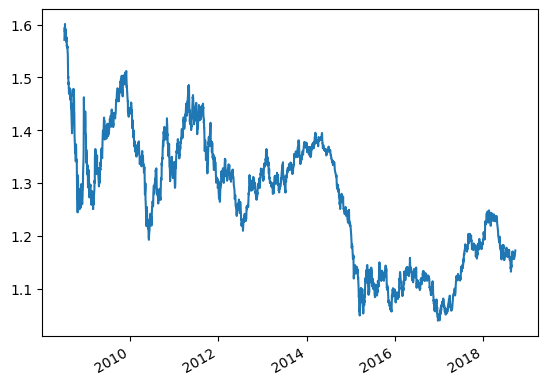

In [ ]:
df5["PX_OPEN"].plot()

<a name="Pivot"></a>
## Pivot

3 parámetros relevantes

- columns: la columna (o columnas) cuyos valores serán las nuevas columnas
- values: columna con la que se rellenaran estos valores
- index: columna cuyo contenido pasará a ser el índice

<img src=https://pandas.pydata.org/docs/_images/reshaping_pivot.png width=400>

Tenemos datos de paro por comunidades:

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/RafaelCaballero/tdm/master/datos/parocomunidades.csv"
df = pd.read_csv(url,encoding="latin1")
df["Comunidad"] = df["Comunidad"].str.strip()
df

,Comunidad,Periodo,Total
0,Andalucía,2023,18.67
1,Andalucía,2022,19.00
2,Andalucía,2021,20.18
3,Andalucía,2020,22.74
4,Andalucía,2019,20.80
...,...,...,...
413,Melilla,2006,9.86
414,Melilla,2005,12.33
415,Melilla,2004,12.49
416,Melilla,2003,19.88


Nos gustaría hacer una gráfica para ver la evolución del paro por años en alguna comunidad concreta, pero para eso deberían ser columnas

In [ ]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,408,409,410,411,412,413,414,415,416,417
Comunidad,Andalucía,Andalucía,Andalucía,Andalucía,Andalucía,Andalucía,Andalucía,Andalucía,Andalucía,Andalucía,...,Melilla,Melilla,Melilla,Melilla,Melilla,Melilla,Melilla,Melilla,Melilla,Melilla
Periodo,2023,2022,2021,2020,2019,2018,2017,2016,2015,2014,...,2011,2010,2009,2008,2007,2006,2005,2004,2003,2002
Total,18.67,19.0,20.18,22.74,20.8,21.26,24.43,28.25,29.83,34.23,...,24.84,24.46,19.87,16.17,17.43,9.86,12.33,12.49,19.88,3.57


No vale! no nos quedan los periodos como filas; lo que necesitamos es convertir Comunidad en columna sin afectar a las demás. Para esto podemos usar [pivot](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pivot.html)

In [ ]:
df2 = df.pivot(index='Periodo', columns='Comunidad', values='Total')
df2

Comunidad,Andalucía,Aragón,"Asturias, Principado de","Balears, Illes",Canarias,Cantabria,Castilla - La Mancha,Castilla y León,Cataluña,Ceuta,Comunitat Valenciana,Extremadura,Galicia,"Madrid, Comunidad de",Melilla,"Murcia, Región de","Navarra, Comunidad Foral de",País Vasco,"Rioja, La"
Periodo,,,,,,,,,,,,,,,,,,,
2002,20.15,6.54,10.12,8.69,11.32,10.58,9.85,10.15,10.61,5.70,10.71,18.91,11.89,6.99,3.57,11.45,5.58,9.64,5.65
2003,18.35,6.53,10.14,10.01,12.04,10.42,9.80,11.02,9.72,9.65,10.68,17.14,13.46,7.16,19.88,10.76,6.16,9.93,6.75
2004,15.99,5.56,10.24,8.09,10.75,11.10,10.20,10.48,9.32,6.59,10.11,17.65,12.47,6.95,12.49,9.96,5.14,9.26,4.68
2005,13.80,5.76,9.30,7.50,10.88,8.01,9.42,8.53,6.63,17.14,8.13,15.16,9.14,5.90,12.33,7.43,5.92,6.45,6.69
2006,12.22,4.99,9.09,6.34,11.37,5.87,8.05,7.58,6.56,14.44,8.48,12.94,7.88,6.46,9.86,7.85,4.59,6.92,6.88
2007,13.96,5.12,8.00,9.35,10.89,4.72,8.10,6.94,6.50,20.18,8.94,14.79,7.46,6.40,17.43,8.25,4.28,5.90,5.88
2008,21.66,9.71,10.00,12.05,20.99,8.81,15.04,11.40,11.75,15.66,14.58,18.11,9.64,10.02,16.17,15.29,8.13,8.48,9.80
2009,26.27,13.57,14.13,19.45,26.77,12.70,19.29,14.21,16.90,24.01,22.09,21.21,12.80,14.48,19.87,21.84,10.51,12.13,13.76
2010,28.04,16.29,16.61,21.78,28.78,14.67,21.72,15.78,17.86,24.83,22.57,23.95,15.62,15.54,24.46,24.45,11.77,10.98,15.58


<Axes: xlabel='Periodo'>

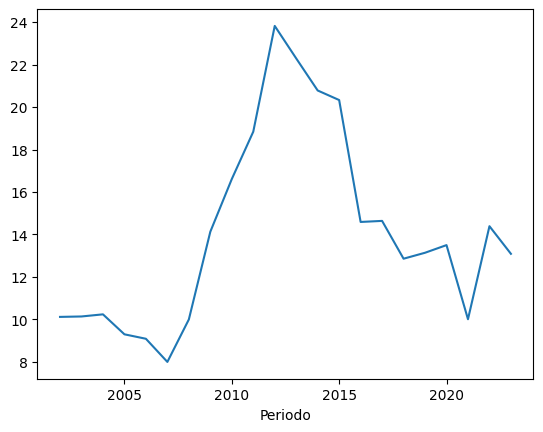

In [ ]:
df2["Asturias, Principado de"].plot()

**Pregunta** ¿Qué hará el código siguiente?

In [ ]:
#df.pivot(index='Comunidad', columns='Periodo', values='Total')

<a name="Melt"></a>
## Melt

[melt](https://pandas.pydata.org/docs/reference/api/pandas.melt.html) es la función contraria, la que pasa del formato ancho al formato largo

En esta ocasión se indican las columnas que no hay que tocar, las que hacen de "clave primaria":

<img src="https://miro.medium.com/max/1400/0*O3SGf68-vlON_H8L.png" width=400>

In [ ]:
df2

Comunidad,Andalucía,Aragón,"Asturias, Principado de","Balears, Illes",Canarias,Cantabria,Castilla - La Mancha,Castilla y León,Cataluña,Ceuta,Comunitat Valenciana,Extremadura,Galicia,"Madrid, Comunidad de",Melilla,"Murcia, Región de","Navarra, Comunidad Foral de",País Vasco,"Rioja, La"
Periodo,,,,,,,,,,,,,,,,,,,
2002,20.15,6.54,10.12,8.69,11.32,10.58,9.85,10.15,10.61,5.70,10.71,18.91,11.89,6.99,3.57,11.45,5.58,9.64,5.65
2003,18.35,6.53,10.14,10.01,12.04,10.42,9.80,11.02,9.72,9.65,10.68,17.14,13.46,7.16,19.88,10.76,6.16,9.93,6.75
2004,15.99,5.56,10.24,8.09,10.75,11.10,10.20,10.48,9.32,6.59,10.11,17.65,12.47,6.95,12.49,9.96,5.14,9.26,4.68
2005,13.80,5.76,9.30,7.50,10.88,8.01,9.42,8.53,6.63,17.14,8.13,15.16,9.14,5.90,12.33,7.43,5.92,6.45,6.69
2006,12.22,4.99,9.09,6.34,11.37,5.87,8.05,7.58,6.56,14.44,8.48,12.94,7.88,6.46,9.86,7.85,4.59,6.92,6.88
2007,13.96,5.12,8.00,9.35,10.89,4.72,8.10,6.94,6.50,20.18,8.94,14.79,7.46,6.40,17.43,8.25,4.28,5.90,5.88
2008,21.66,9.71,10.00,12.05,20.99,8.81,15.04,11.40,11.75,15.66,14.58,18.11,9.64,10.02,16.17,15.29,8.13,8.48,9.80
2009,26.27,13.57,14.13,19.45,26.77,12.70,19.29,14.21,16.90,24.01,22.09,21.21,12.80,14.48,19.87,21.84,10.51,12.13,13.76
2010,28.04,16.29,16.61,21.78,28.78,14.67,21.72,15.78,17.86,24.83,22.57,23.95,15.62,15.54,24.46,24.45,11.77,10.98,15.58


In [ ]:
df2.melt()

,Comunidad,value
0,Andalucía,20.15
1,Andalucía,18.35
2,Andalucía,15.99
3,Andalucía,13.80
4,Andalucía,12.22
...,...,...
413,"Rioja, La",9.89
414,"Rioja, La",10.36
415,"Rioja, La",10.45
416,"Rioja, La",8.60


¿Qué pasa con el año? Una posibilidad es convertirlo en una columna normal, y luego usarlo como identificador de fila

In [ ]:
df2_año = df2.copy()
df2_año["año"] = df2.index
df2_año

Comunidad,Andalucía,Aragón,"Asturias, Principado de","Balears, Illes",Canarias,Cantabria,Castilla - La Mancha,Castilla y León,Cataluña,Ceuta,Comunitat Valenciana,Extremadura,Galicia,"Madrid, Comunidad de",Melilla,"Murcia, Región de","Navarra, Comunidad Foral de",País Vasco,"Rioja, La",año
Periodo,,,,,,,,,,,,,,,,,,,,
2002,20.15,6.54,10.12,8.69,11.32,10.58,9.85,10.15,10.61,5.70,10.71,18.91,11.89,6.99,3.57,11.45,5.58,9.64,5.65,2002
2003,18.35,6.53,10.14,10.01,12.04,10.42,9.80,11.02,9.72,9.65,10.68,17.14,13.46,7.16,19.88,10.76,6.16,9.93,6.75,2003
2004,15.99,5.56,10.24,8.09,10.75,11.10,10.20,10.48,9.32,6.59,10.11,17.65,12.47,6.95,12.49,9.96,5.14,9.26,4.68,2004
2005,13.80,5.76,9.30,7.50,10.88,8.01,9.42,8.53,6.63,17.14,8.13,15.16,9.14,5.90,12.33,7.43,5.92,6.45,6.69,2005
2006,12.22,4.99,9.09,6.34,11.37,5.87,8.05,7.58,6.56,14.44,8.48,12.94,7.88,6.46,9.86,7.85,4.59,6.92,6.88,2006
2007,13.96,5.12,8.00,9.35,10.89,4.72,8.10,6.94,6.50,20.18,8.94,14.79,7.46,6.40,17.43,8.25,4.28,5.90,5.88,2007
2008,21.66,9.71,10.00,12.05,20.99,8.81,15.04,11.40,11.75,15.66,14.58,18.11,9.64,10.02,16.17,15.29,8.13,8.48,9.80,2008
2009,26.27,13.57,14.13,19.45,26.77,12.70,19.29,14.21,16.90,24.01,22.09,21.21,12.80,14.48,19.87,21.84,10.51,12.13,13.76,2009
2010,28.04,16.29,16.61,21.78,28.78,14.67,21.72,15.78,17.86,24.83,22.57,23.95,15.62,15.54,24.46,24.45,11.77,10.98,15.58,2010


In [ ]:
df2_año.melt(id_vars="año")

,año,Comunidad,value
0,2002,Andalucía,20.15
1,2003,Andalucía,18.35
2,2004,Andalucía,15.99
3,2005,Andalucía,13.80
4,2006,Andalucía,12.22
...,...,...,...
413,2019,"Rioja, La",9.89
414,2020,"Rioja, La",10.36
415,2021,"Rioja, La",10.45
416,2022,"Rioja, La",8.60


También se puede decir que mantenga el índice original

In [ ]:
df2.melt(ignore_index=False)

,Comunidad,value
Periodo,,
2002,Andalucía,20.15
2003,Andalucía,18.35
2004,Andalucía,15.99
2005,Andalucía,13.80
2006,Andalucía,12.22
...,...,...
2019,"Rioja, La",9.89
2020,"Rioja, La",10.36
2021,"Rioja, La",10.45


A veces queremos unir algunas columnas, no todas

In [ ]:
url = "https://github.com/RafaelCaballero/tdm/raw/refs/heads/master/datos/Ventas%20Videojuegos.xlsx"

df = pd.read_excel(url).drop(columns=["Ventas Global"])
df.columns=["Nombre",	"Plataforma",	"Año",	"Genero",	"Editorial",	"Nort.Am",	"EU",	"JP",	"Otros"]
df

,Nombre,Plataforma,Año,Genero,Editorial,Nort.Am,EU,JP,Otros
0,Wii Sports,Wii,2006,Sports,Nintendo,41.50,29.02,3.77,8.46
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00
...,...,...,...,...,...,...,...,...,...
16321,Farming 2017 - The Simulation,PS4,2016,Simulation,UIG Entertainment,0.00,0.01,0.00,0.00
16322,Rugby Challenge 3,XOne,2016,Sports,Alternative Software,0.00,0.01,0.00,0.00
16323,Chou Ezaru wa Akai Hana: Koi wa Tsuki ni Shiru...,PSV,2016,Action,dramatic create,0.00,0.00,0.01,0.00
16324,Phantasy Star Online 2 Episode 4: Deluxe Package,PSV,2017,Role-Playing,Sega,0.00,0.00,0.01,0.00


Las últimas colmumnas indican las ventas del video juego en norteamérica, Europa, Japón, y otros países.  Queremos unirlasen una sola

In [ ]:
df.melt(value_vars=["Nort.Am",	"EU",	"JP",	"Otros"])


,variable,value
0,Nort.Am,41.50
1,Nort.Am,29.08
2,Nort.Am,15.85
3,Nort.Am,15.75
4,Nort.Am,11.27
...,...,...
65299,Otros,0.00
65300,Otros,0.00
65301,Otros,0.00
65302,Otros,0.00


El problema es que hemos perdido el resto de columnas, pero ya sabemos cómo solucionar esto:


In [ ]:
mantener = ["Nombre",	"Plataforma",	"Año",	"Genero",	"Editorial"]
agrupar = ["Nort.Am",	"EU",	"JP",	"Otros"]
df.melt(id_vars = mantener, value_vars=agrupar)


,Nombre,Plataforma,Año,Genero,Editorial,variable,value
0,Wii Sports,Wii,2006,Sports,Nintendo,Nort.Am,41.50
1,Super Mario Bros.,NES,1985,Platform,Nintendo,Nort.Am,29.08
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,Nort.Am,15.85
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,Nort.Am,15.75
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,Nort.Am,11.27
...,...,...,...,...,...,...,...
65299,Farming 2017 - The Simulation,PS4,2016,Simulation,UIG Entertainment,Otros,0.00
65300,Rugby Challenge 3,XOne,2016,Sports,Alternative Software,Otros,0.00
65301,Chou Ezaru wa Akai Hana: Koi wa Tsuki ni Shiru...,PSV,2016,Action,dramatic create,Otros,0.00
65302,Phantasy Star Online 2 Episode 4: Deluxe Package,PSV,2017,Role-Playing,Sega,Otros,0.00


Pregunta fácil ¿cómo se seleccionaría ahora todas las ventas en Europa?

**Ejemplo** Consideramos el fichero

In [ ]:
import pandas as pd
url = "https://github.com/RafaelCaballero/tdm/raw/master/datos/clientes.xlsx"
df = pd.read_excel(url)
df

,cliente,documento,entregado,tasas
0,2910167,1687488,0,464
1,5799708,152861,0,112
2,7248498,1789308,0,730
3,5799708,1082327,0,621
4,6989459,1537165,0,496
...,...,...,...,...
495,3515207,206323,0,811
496,6945307,1007147,1,998
497,2910167,1303799,1,876
498,5651729,955457,0,622


Queremos el total de tasas por cliente desglosadas en dos columnas, una para entregado=1 y otra para entregado=0

In [ ]:
df.groupby('userid').agg(
      t_media=('T', 'mean'),
      b_media=('B', 'mean')
)

,t_media,b_media
userid,,
5405222,0.0,1.0
12599452,0.0,0.0
13058862,0.0,0.0
14275426,0.0,1.0
14743035,0.0,0.0
...,...,...
1321072999966167048,0.0,0.0
1321142203549421568,0.0,0.0
1321808025347366912,0.0,0.0
